In [25]:
import numpy as np
import pandas as pd
import re
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import transformers
from transformers import pipeline, XLMRobertaTokenizer

In [4]:
book_reviews_data = pd.read_csv("book_reviews_sample.csv")
book_reviews_data.head()

,index,reviewText,rating
0,11494,Clean and funny. A bit busy with all the diffe...,3
1,984,Alex a sexy hot cop and the PhD candidate. Wha...,4
2,1463,Good thing that this is a free story. I read i...,1
3,10342,"Action, action, action! Equipment keeps gettin...",4
4,5256,this was hands down the worse book i have ever...,1


In [5]:
book_reviews_data['reviewText_clean'] = book_reviews_data['reviewText'].str.lower()

In [7]:
book_reviews_data['reviewText_clean'] = book_reviews_data.apply(lambda x: re.sub(r"([^\w\s])", "", x['reviewText_clean']), axis=1)

In [8]:
book_reviews_data.head()

,index,reviewText,rating,reviewText_clean
0,11494,Clean and funny. A bit busy with all the diffe...,3,clean and funny a bit busy with all the differ...
1,984,Alex a sexy hot cop and the PhD candidate. Wha...,4,alex a sexy hot cop and the phd candidate what...
2,1463,Good thing that this is a free story. I read i...,1,good thing that this is a free story i read it...
3,10342,"Action, action, action! Equipment keeps gettin...",4,action action action equipment keeps getting b...
4,5256,this was hands down the worse book i have ever...,1,this was hands down the worse book i have ever...


In [10]:
book_reviews_data['reviewText_clean'][0]

'clean and funny a bit busy with all the different plots going on but overall a good read bye now'

In [11]:
vader_sentiment = SentimentIntensityAnalyzer()

In [12]:
book_reviews_data['vader_sentiment_score'] = book_reviews_data.apply(lambda review: vader_sentiment.polarity_scores(review['reviewText_clean'])['compound'], axis=1)

In [18]:
book_reviews_data.head()

,index,reviewText,rating,reviewText_clean,vader_sentiment_score
0,11494,Clean and funny. A bit busy with all the diffe...,3,clean and funny a bit busy with all the differ...,0.7684
1,984,Alex a sexy hot cop and the PhD candidate. Wha...,4,alex a sexy hot cop and the phd candidate what...,0.9325
2,1463,Good thing that this is a free story. I read i...,1,good thing that this is a free story i read it...,0.6740
3,10342,"Action, action, action! Equipment keeps gettin...",4,action action action equipment keeps getting b...,0.6652
4,5256,this was hands down the worse book i have ever...,1,this was hands down the worse book i have ever...,-0.4767


In [21]:
bins = [-1, -0.1, 0.1, 1]
names = ['positive', 'negative', 'neutral']

book_reviews_data['vader_sentiment_labels'] = pd.cut(book_reviews_data['vader_sentiment_score'], labels=names, bins=bins)

In [22]:
book_reviews_data.head()

,index,reviewText,rating,reviewText_clean,vader_sentiment_score,vader_sentiment_labels
0,11494,Clean and funny. A bit busy with all the diffe...,3,clean and funny a bit busy with all the differ...,0.7684,neutral
1,984,Alex a sexy hot cop and the PhD candidate. Wha...,4,alex a sexy hot cop and the phd candidate what...,0.9325,neutral
2,1463,Good thing that this is a free story. I read i...,1,good thing that this is a free story i read it...,0.6740,neutral
3,10342,"Action, action, action! Equipment keeps gettin...",4,action action action equipment keeps getting b...,0.6652,neutral
4,5256,this was hands down the worse book i have ever...,1,this was hands down the worse book i have ever...,-0.4767,positive


<Axes: xlabel='vader_sentiment_labels'>

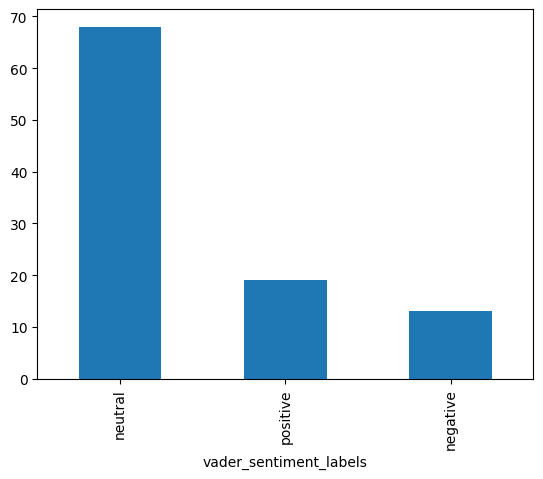

In [24]:
book_reviews_data['vader_sentiment_labels'].value_counts().plot.bar()

In [26]:
model_path = r"C:\Users\shubghos\Desktop\Projects\models\twitter-xlm-roberta-base-sentiment"
tok = XLMRobertaTokenizer.from_pretrained(model_path, use_fast=False)
sentiment_pipeline = pipeline("sentiment-analysis", model=model_path, tokenizer=tok)

Device set to use cpu


In [29]:
transformers_labels = []

for review in book_reviews_data['reviewText_clean'].values:
    sentiment_list = sentiment_pipeline(review)
    sentiment_label = [sent['label'] for sent in sentiment_list]
    transformers_labels.append(sentiment_label)

book_reviews_data['transformer_sentiment_labels'] = transformers_labels

<Axes: xlabel='transformer_sentiment_labels'>

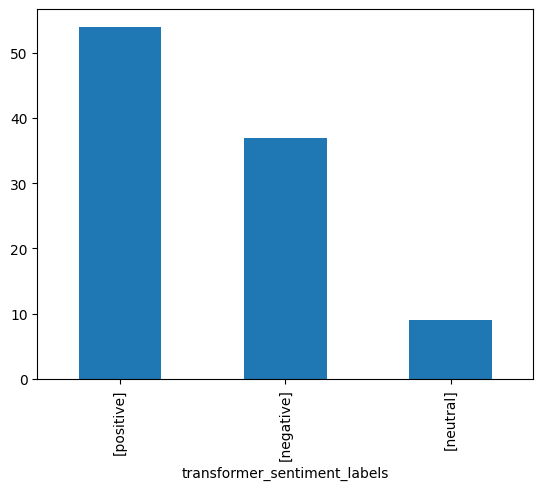

In [30]:
book_reviews_data['transformer_sentiment_labels'].value_counts().plot.bar()